In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import itertools
from torch.nn import functional as F

np.random.seed(42)
torch.manual_seed(42)

dtype = torch.float32
complex_dtype = torch.complex64 if dtype == torch.float32 else torch.complex128

# go-mHC Class
class GeneralizedUnistochastic(nn.Module):
    def __init__(self, d, s, batch_size=1, orthonormal=True, init=torch.rand):
        super().__init__()
        self.d = d
        self.s = s
        self.batch_size = batch_size
        self.total_dim = d * s
        
        # Add a batch dimension: (batch_size, ds, ds)
        self.raw_u = nn.Parameter(init(
            self.batch_size, self.total_dim, self.total_dim, 
            dtype=dtype if orthonormal else complex_dtype
        ))
        
        # self.softmax = nn.Softmax(dim=-1)

    def get_unitary(self):
        # Batch-wise adjoint and matrix exponential
        ru = self.raw_u
        # ru = self.softmax(self.raw_u)
        
        X = ru - ru.adjoint() 
        # Can instead do matrix exp, but that is worse for many reasons (stability, number of operations, etc.)
        # return torch.matrix_exp(X)
        
        # Cayley Transform
        I = torch.eye(self.total_dim, device=X.device).unsqueeze(0).expand(self.batch_size, -1, -1)
        U = torch.linalg.solve(I - X, I + X)
        return U

    def forward(self):
        U = self.get_unitary()
        
        # Reshape to (batch, d, s, d, s) -> (batch, d, d, s, s)
        blocks = U.view(self.batch_size, self.d, self.s, self.d, self.s).permute(0, 1, 3, 2, 4)
        
        # Sum across the internal s x s blocks for the whole batch
        bistochastic_matrices = torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / self.s
        
        return bistochastic_matrices

class AveragedUnistochastic(nn.Module):
    def __init__(self, d, s, batch_size=1, free_s=False):
        super().__init__()
        self.d = d
        self.s = s
        self.batch_size = batch_size
        self.free_s = free_s
    
        self.raw_u = nn.Parameter(torch.rand(
            self.batch_size, self.s, self.d, self.d, 
            dtype=dtype
        ))
        
        # if self.s >= 2:
        #     with torch.no_grad():
        #         # set second matrix init to something that makes identity
        #         self.raw_u[:, 1, :, :] = 10*torch.rand(
        #             self.batch_size, self.d, self.d, 
        #             dtype=torch.float32
        #         )

        if free_s:
            self.s_param = nn.Parameter(torch.rand(self.s, dtype=dtype))
        
    def get_unitary(self):
        # Batch-wise adjoint and cayley transform using solve
        X = self.raw_u - self.raw_u.transpose(-2, -1)
        I = torch.eye(self.d, dtype=X.dtype, device=X.device).expand_as(X)
        return torch.linalg.solve(I - 0.5 * X, I + 0.5 * X)
    
    def forward(self):
        U = self.get_unitary()
        
        if self.free_s:
            # map learned s_param to values between 0 and 1 that sum to 1 using sigmoid and normalization
            sigmoid_s = torch.sigmoid(self.s_param)
            prefactors = sigmoid_s / sigmoid_s.sum()
        # else:
        #     prefactors = 1.0 / self.s
        
        # take squared of U
        u_squared = torch.abs(U) ** 2
        
        # average over s
        if self.free_s:
            # print("shapes", u_squared.shape, prefactors.shape)
            s_avg = torch.einsum('bsot, s -> bot', u_squared, prefactors)
        else:
            s_avg = u_squared.sum(dim=1) / self.s
        
        return s_avg
    
    
# get all nxn permutation matrices as a tensor of shape (n!, n, n)
def get_permutation_matrices(n):
    perms = list(itertools.permutations(range(n)))
    matrices = [torch.zeros(n, n, dtype=dtype).index_put_((torch.arange(n), torch.tensor(p)), torch.tensor(1.0, dtype=dtype)) for p in perms]
    return torch.stack(matrices)

# Sinkhorn normalization to make a matrix doubly stochastic (same as in mHC paper)
# Repeatedly normalize rows and columns until convergence (or max iterations)
def sinkhorn(M, num_iters=20):
    # check if M is already doubly stochastic
    if torch.allclose(M.sum(dim=-1), torch.ones(M.shape[0], M.shape[1], device=M.device), atol=1e-8) and torch.allclose(M.sum(dim=-2), torch.ones(M.shape[0], M.shape[2], device=M.device), atol=1e-8):
        return M
    # Works on [B, n, n]
    for _ in range(num_iters):
        M = abs(M)  # Ensure non-negativity
        M = M / M.sum(dim=-1, keepdim=True)  # Row
        M = M / M.sum(dim=-2, keepdim=True)  # Col
    return M

# Class that implements both mHC-lite and KromHC
# To do KromHC, you have multiple num_factors and N=2 (num_factors is log2 of the dimension of the matrix)
# To do mHC-lite, you have num_factors=1 and N=n (the dimension of the matrix)
class GeneralizedKromHC(nn.Module):
    def __init__(self, num_factors, N=3, batch_size=1):
        super().__init__()
        self.num_factors = num_factors
        self.N = N
        self.batch_size = batch_size
        
        # Precompute all N! permutation matrices
        perms = list(itertools.permutations(range(N)))
        self.num_perms = len(perms)
        
        perm_mats = torch.zeros((self.num_perms, N, N), dtype=dtype)
        for i, p in enumerate(perms):
            for row, col in enumerate(p):
                perm_mats[i, row, col] = 1.0
        self.register_buffer('perm_mats', perm_mats)

        # Logits for the convex combination
        self.coeffs = nn.Parameter(torch.randn(batch_size, num_factors, self.num_perms))

    def forward(self):
        weights = F.softmax(self.coeffs, dim=-1) 
        
        # Build factor matrices: (Batch, Num_Factors, N, N)
        factor_mats = (weights.view(self.batch_size, self.num_factors, self.num_perms, 1, 1) * self.perm_mats.view(1, 1, self.num_perms, self.N, self.N)).sum(dim=2)
        
        res = factor_mats[:, 0, :, :]
        
        for k in range(1, self.num_factors):
            mat = factor_mats[:, k, :, :]
            curr_dim = res.shape[1]
            
            res_expanded = res.view(self.batch_size, curr_dim, 1, curr_dim, 1)
            mat_expanded = mat.view(self.batch_size, 1, self.N, 1, self.N)
            
            res = (res_expanded * mat_expanded).reshape(
                self.batch_size, curr_dim * self.N, curr_dim * self.N
            )
        return res

In [2]:
class Sinkhorn(nn.Module):
    def __init__(self, d, batch_size=1, iters=20, init=torch.randn):
        super().__init__()
        self.d = d
        self.batch_size = batch_size
        self.iters = iters
        
        self.log_alpha = nn.Parameter(init(batch_size, d, d))

    def sinkhorn_knopps(self, log_alpha):
        for _ in range(self.iters):
            log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)
            log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-2, keepdim=True)
        
        return log_alpha.exp()

    def forward(self):
        bistochastic_matrices = self.sinkhorn_knopps(self.log_alpha)
        return bistochastic_matrices
    
class SinkhornLinear(nn.Module):
    def __init__(self, d, batch_size=1, iters=20, epsilon=1e-12):
        super().__init__()
        self.d = d
        self.batch_size = batch_size
        self.iters = iters
        self.epsilon = epsilon  # Safeguard against division by zero
        
        # Initialize weights. We use exponential or positive values 
        # because Sinkhorn requires non-negative entries.
        self.W = nn.Parameter(torch.rand(batch_size, d, d))

    def forward(self):
        # Ensure non-negativity (M = abs(M) or M = relu(M))
        # Using abs() as in your snippet
        M = torch.abs(self.W)
        
        for _ in range(self.iters):
            # Row normalization
            # We add epsilon to prevent 0/0 = NaN
            M = M / (M.sum(dim=-1, keepdim=True) + self.epsilon)
            
            # Column normalization
            M = M / (M.sum(dim=-2, keepdim=True) + self.epsilon)
            
        return M

# Target Generation Code

In [3]:
import torch

def generate_haar_unitary_batch(d, batch_size=1, device='cpu', dtype=complex_dtype):
    """
    Generates a batch of d x d Haar random unitaries.
    Output shape: (batch_size, d, d)
    """
    if d > 1000 and batch_size < 25:
        raise ValueError("Did you swap d and batch_size?")
    # 1. Generate batch of random complex matrices
    # Using complex128 for higher numerical precision in testing
    z = torch.randn(batch_size, d, d, dtype=dtype, device=device)
    
    # 2. Batch QR decomposition
    q, r = torch.linalg.qr(z)
    
    # 3. Extract diagonals for the whole batch
    # diag_r shape: (batch_size, d)
    diag_r = torch.diagonal(r, dim1=-2, dim2=-1)
    
    # 4. Compute phases and reshape for broadcasting
    # phases shape: (batch_size, 1, d) to multiply against columns of Q
    phases = (diag_r / torch.abs(diag_r)).unsqueeze(-2)
    
    # 5. Apply phase correction
    u = q * phases
    
    return u

import torch

def generate_haar_orthogonal_batch(d, batch_size, device='cpu', dtype=dtype):
    """
    Generates a batch of d x d Haar-random orthogonal matrices.
    Output shape: (batch_size, d, d)
    """
    assert d < 100
    
    # 1. Generate real Gaussian random matrix
    a = torch.randn(batch_size, d, d, dtype=dtype, device=device)
    
    # 2. QR decomposition
    q, r = torch.linalg.qr(a)
    
    # 3. Extract diagonal of R and compute signs
    diag_r = torch.diagonal(r, dim1=-2, dim2=-1)
    # torch.sign returns -1, 0, or 1. Gaussian entries are almost never 0.
    signs = torch.sign(diag_r).unsqueeze(-2)
    
    # 4. Apply sign correction to Q
    ortho_batch = q * signs
    
    return ortho_batch

def generate_uniform_params(n, batch_size=1):
  """
  Generates n random parameters that sum to 1, uniformly distributed.

  Args:
    n: The number of parameters to generate.
    batch_size: The number of sets of parameters to generate.
  Returns:
    A numpy array of shape (batch_size, n) where each row sums to 1.
  """
  # Alpha parameter: use 1.0 for a uniform distribution over the simplex
  alpha = np.ones(n)
  # Draw samples
  params = np.random.dirichlet(alpha, size=batch_size)
  return torch.Tensor(params)

In [4]:
import math

def generate_birkhoff_using_SK(d, batch_size=1, device='cpu'):
    return sinkhorn(torch.rand(batch_size, d, d, device=device))

def generate_birkhoff_using_haar_unitary(s):
    def _generate_birkhoff_using_haar_unitary(d, batch_size=1, device='cpu', return_generator=False):
        """
        Generates a batch of d x d bistochastic matrices using the go-mHC construction with Haar random unitaries.
        """
        U = generate_haar_unitary_batch(d * s, batch_size, device=device)
        
        blocks = U.view(batch_size, d, s, d, s).permute(0, 1, 3, 2, 4)
            
        # Sum across the internal s x s blocks for the whole batch
        if return_generator:
            return torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / s, U
        else:
            return torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / s
    
    _generate_birkhoff_using_haar_unitary.__name__ = f"generate_birkhoff_using_haar_unitary(s={s})"
    return _generate_birkhoff_using_haar_unitary

def generate_birkhoff_using_haar_orthogonal(s):
    def _generate_birkhoff_using_haar_orthogonal(d, batch_size=1, device='cpu', return_generator=False):
        """
        Generates a batch of d x d bistochastic matrices using the go-mHC construction with Haar random orthogonal matrices.
        """
        U = generate_haar_orthogonal_batch(d * s, batch_size, device=device)
        
        blocks = U.view(batch_size, d, s, d, s).permute(0, 1, 3, 2, 4)
            
        # Sum across the internal s x s blocks for the whole batch
        if return_generator:
            return torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / s, U
        else:
            return torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / s
    _generate_birkhoff_using_haar_orthogonal.__name__ = f"generate_birkhoff_using_haar_orthogonal(s={s})"
    return _generate_birkhoff_using_haar_orthogonal

def generate_birkhoff_using_BN_theorem(d, batch_size=1, device='cpu', safe=True):
    if d > 7 and safe:
        raise ValueError("d! is too large, use safe=False to bypass.")
    
    num_permutations = math.factorial(d)
    prefactors = generate_uniform_params(num_permutations, batch_size=batch_size)
    
    # Get permutation matrices on the correct device and dtype
    perm_mats = get_permutation_matrices(d).to(device=device, dtype=dtype)
    
    # Build target matrices using einsum as a weighted sum of permutation matrices
    target_mats = torch.einsum('bp, pjk -> bjk', prefactors, perm_mats)
    
    return target_mats

def generate_random_eigval_targets_unit_circle(d, batch_size=1, device='cpu'):
    # Generate random eigenvalues on the unit circle
    angles = torch.rand(batch_size, device=device, dtype=dtype) * 2 * math.pi
    mags = torch.rand(batch_size, device=device, dtype=dtype) ** 0.5
    eigvals = mags * torch.exp(1j * angles)
    return eigvals

def generate_random_eigval_targets_complex_square(d, batch_size=1, device='cpu'):
    real = torch.rand(batch_size, device=device, dtype=dtype) * 2 - 1
    imag = torch.rand(batch_size, device=device, dtype=dtype) * 2 - 1
    return real + 1j * imag

def generate_grid_eigval_targets_complex_square(d, batch_size=1, device='cpu'):
    # Generate a grid of eigenvalues in the complex plane
    num_points_per_axis = int(batch_size ** 0.5)
    second_axis_points = int(batch_size / num_points_per_axis)
    real_parts = torch.linspace(-1, 1, num_points_per_axis, device=device, dtype=dtype)
    imag_parts = torch.linspace(-1, 1, second_axis_points, device=device, dtype=dtype)
    grid_real, grid_imag = torch.meshgrid(real_parts, imag_parts)
    eigvals = grid_real.flatten() + 1j * grid_imag.flatten()
    return eigvals[:batch_size]  # Return only the requested number of eigenvalues

# Toy Models

In [ ]:
class DatasetModel():
    Y_Ytilde_type = "real"
    Y_Ytilde_shape = "vec"
    def __init__(self, model, targets, d, batch_size=64, dataset_size=100, sparsity=0.0, noise_mag=1e-3, target_nonconforming_noise=0, device='cpu'):
        
        self.model = model
        self.targets = targets + (target_nonconforming_noise * torch.rand_like(targets, dtype=dtype, device=device))
        
        self.d = d
        self.batch_size = batch_size
        self.dataset_size = dataset_size
        self.device = device
        self.sparsity = sparsity
        self.noise_mag = noise_mag
        self.target_nonconforming_noise = target_nonconforming_noise
        
        X = torch.rand(self.batch_size, self.dataset_size, self.d, device=self.device, dtype=dtype)
        sparse_mask = (torch.rand_like(X) > self.sparsity).to(dtype)
        X = X * sparse_mask.sum(dim=-1, keepdim=True)
        Y = torch.einsum('bij,bdj->bdi', self.targets, X) + (self.noise_mag * torch.rand(self.batch_size, self.dataset_size, self.d, device=self.device, dtype=dtype))
        
        self.X = X
        self.Y = Y
    
    def parameters(self):
        return self.model.parameters()
    
    def get_doubly_stochastic_matrix(self):
        return self.model()
    
    def get_Y_YTilde(self):
        output = self.model()
        tildeY = torch.einsum('bij,bdj->bdi', output, self.X)
        return self.Y, tildeY
    
    
class TargetMatrixModel():
    Y_Ytilde_type = "real"
    Y_Ytilde_shape = "vec"
    def __init__(self, model, targets, d, batch_size=64, dataset_size=100, sparsity=0.0, noise_mag=1e-3, target_nonconforming_noise=0, device='cpu'):
        
        self.model = model
        self.targets = targets + (target_nonconforming_noise * torch.rand_like(targets, dtype=dtype, device=device))
        
        self.d = d
        self.batch_size = batch_size
        self.dataset_size = dataset_size
        self.device = device
        self.sparsity = sparsity
        self.noise_mag = noise_mag
        self.target_nonconforming_noise = target_nonconforming_noise
        
    def parameters(self):
        return self.model.parameters()
    
    def get_doubly_stochastic_matrix(self):
        return self.model()
    
    def get_Y_YTilde(self):
        output = self.model()
        noise = self.noise_mag * torch.rand_like(self.targets, dtype=dtype, device=self.device)
        return self.targets + noise, output
    
class DatasetModelWithStaticHpre(DatasetModel):
    Y_Ytilde_type = "real"
    Y_Ytilde_shape = "num"
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.Hpre_layer_target = torch.rand(self.batch_size, self.d, device=self.device, dtype=dtype)  # Target for the pre_layer to learn        
        self.Y = torch.einsum('bj,bkj->bk', self.Hpre_layer_target, self.Y)  # Apply the same pre_layer transformation to targets
        
    def get_Y_YTilde(self):
        output = self.model()
        tildeY = torch.einsum('bij,bdj->bdi', output, self.X)
        tildeY = torch.einsum('bi,bdi->bd', self.Hpre_layer_target, tildeY)  # Apply the same pre_layer transformation to the output
        return self.Y, tildeY

class DatasetModelWithLearnedHpre(DatasetModelWithStaticHpre):
    Y_Ytilde_type = "real"
    Y_Ytilde_shape = "num"
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # pre_layer_init = torch.ones(self.d, device=self.device) + 0.1*torch.randn(self.d, device=self.device)  # Initialize around the identity transformation
        self.H_pre = nn.Parameter(self.Hpre_layer_target.clone() + 0.1*torch.randn(self.d, device=self.device), requires_grad=True)
    
    def parameters(self):
        # return [self.model.parameters(), self.H_pre]
        yield from self.model.parameters()
        yield self.H_pre
    
    def get_Y_YTilde(self):
        output = self.model()
        tildeY = torch.einsum('bij,bdj->bdi', output, self.X)
        tildeY = torch.einsum('bi,bdi->bd', self.H_pre, tildeY)  # Apply the learned pre_layer transformation to the output
        return self.Y, tildeY
    
# given an eigenvalue target array, have Y be the eigval of interest and tildeY be the closest eigenvalue of the output to that target
class TargetEigenvalueModel():
    Y_Ytilde_type = "complex"
    Y_Ytilde_shape = "vec"
    def __init__(self, model, targets, d, batch_size=64, dataset_size=100, sparsity=0.0, noise_mag=1e-3, target_nonconforming_noise=0, device='cpu'):
        
        self.model = model
        self.target_eigvals = targets + (target_nonconforming_noise * torch.rand_like(targets, dtype=targets.dtype, device=device))
        
        self.d = d
        self.batch_size = batch_size
        self.dataset_size = dataset_size
        self.device = device
        self.sparsity = sparsity
        self.noise_mag = noise_mag
        self.target_nonconforming_noise = target_nonconforming_noise
        
    def parameters(self):
        return self.model.parameters()
    
    def get_doubly_stochastic_matrix(self):
        return self.model()
    
    def get_Y_YTilde(self):
        output = self.model()
        # Get eigenvalues of the output
        eigvals = torch.linalg.eigvals(output)
        # print(eigvals.shape, self.target_eigvals.shape)
        
        diff = abs(eigvals - self.target_eigvals.unsqueeze(-1))**2

        selected_eigvals = eigvals[torch.arange(self.batch_size), diff.argmin(dim=-1)]
        
        return self.target_eigvals, selected_eigvals

(tensor([ 0.1054-0.5150j, -0.7937+0.8692j, -0.7679+0.8610j, -0.8129-0.0382j,
         -0.2710-0.8025j,  0.8833-0.3227j,  0.3909-0.2674j, -0.1186+0.0165j,
          0.2058-0.9067j,  0.3982+0.1853j,  0.0058-0.4159j, -0.8066-0.2560j,
         -0.6161-0.5165j, -0.6794-0.2111j, -0.0254-0.9287j, -0.9154-0.5302j,
         -0.1818+0.0921j, -0.3657+0.6553j,  0.9814+0.9087j,  0.8128-0.7565j,
          0.5809+0.4199j,  0.0561-0.5637j, -0.3238-0.7732j,  0.2551-0.0440j,
         -0.6909-0.5736j, -0.4265-0.8612j, -0.2009-0.9345j, -0.2350-0.6693j,
         -0.9473+0.8217j,  0.3975+0.5577j,  0.8235-0.3958j, -0.5516-0.6693j,
          0.2696-0.7692j, -0.1160-0.5905j, -0.0365-0.4115j,  0.0583+0.6006j,
          0.8666+0.3273j,  0.1340-0.3854j, -0.6327+0.6884j, -0.3597-0.6212j,
          0.4885-0.8147j,  0.3121+0.2183j,  0.0194-0.5514j, -0.1320+0.2845j,
         -0.3891+0.8472j, -0.3549-0.4729j, -0.5275-0.6978j,  0.1639+0.3764j,
          0.2808-0.9031j,  0.7657+0.8922j, -0.2259-0.4723j,  0.0716+0.4835j,

In [6]:
from dataclasses import dataclass, field
import tqdm

@dataclass(frozen=True, eq=True)
class go_mHC_run():
    s: int
    orthonormal: bool = True
    legend_name: str = field(default="", compare=False)

    def __str__(self):
        return self.__class__.__name__ + f"(s={self.s}, {'Q' if self.orthonormal else 'U'})"
    
    @property
    def name(self):
        if self.legend_name:
            return self.legend_name
        return f"go-$m$HC ($s={self.s}$, Q)" if self.orthonormal else f"go-$m$HC ($s={self.s}$, U)"
    
@dataclass(frozen=True, eq=True)
class KromHC_run():
    ik: int = 2
    legend_name: str = field(default="", compare=False)

    def __str__(self):
        return self.__class__.__name__ + f"(ik={self.ik})"
    
    @property
    def name(self):
        if self.legend_name:
            return self.legend_name
        return f"KromHC ik={self.ik}" if self.ik != 2 else "KromHC"
    
@dataclass(frozen=True, eq=True)
class mHC_lite_run():
    max_safe_d: int = 7
    legend_name: str = field(default="", compare=False)

    def __str__(self):
        return self.__class__.__name__ + f"(max_safe_d={self.max_safe_d})"
    @property
    def name(self):
        if self.legend_name:
            return self.legend_name
        return f"$m$HC-lite"
    
@dataclass(frozen=True, eq=True)
class SK_run():
    iters: int = 20
    linear: bool = False
    legend_name: str = field(default="", compare=False)

    def __str__(self):
        return (f"Sinkhorn-Knopp Linear" if self.linear else f"Sinkhorn-Knopp") + f"(iters={self.iters}, linear={self.linear})"
    
    @property
    def name(self):
        if self.legend_name:
            return self.legend_name
        return f"Sinkhorn-Knopp Linear" if self.linear else f"Sinkhorn-Knopp"
    
def build_model(method_dataclass, d: int, B: int):
    if isinstance(method_dataclass, go_mHC_run):
        return GeneralizedUnistochastic(d, method_dataclass.s, B, orthonormal=method_dataclass.orthonormal)
    elif isinstance(method_dataclass, mHC_lite_run):
        if d > method_dataclass.max_safe_d:
            return None
        return GeneralizedKromHC(num_factors=1, N=d, batch_size=B)
    elif isinstance(method_dataclass, KromHC_run):
        if int(np.log(d) / np.log(method_dataclass.ik)) != np.log(d) / np.log(method_dataclass.ik):
            return None
        return GeneralizedKromHC(num_factors=int(np.log(d) / np.log(method_dataclass.ik)), N=method_dataclass.ik, batch_size=B)
    elif isinstance(method_dataclass, SK_run):
        if method_dataclass.linear:
            return SinkhornLinear(d, B, iters=method_dataclass.iters)
        else:
            return Sinkhorn(d, B, iters=method_dataclass.iters)
    
    raise ValueError("Unknown method dataclass")

### Caching Helpers

In [7]:
from functools import cache

import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# --- Core Experiment Function ---
import pickle
import os
from functools import wraps
from frozendict import frozendict
# from dataclasses import asdict

def file_cache(filename):
    """
    A decorator that caches the result of a function to a file.
    The cache persists across different runs of the program.
    Note: This simple version works best for functions with no arguments
    or if all calls use the same arguments, as it uses a single cache file.
    """
    USE_CACHE = True
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            # A more robust implementation would use a key based on args/kwargs
            # in the filename if different inputs are expected.
            cache_file = filename 
            if not USE_CACHE:
                print("Skipping Cache Lookup")
                return func(*args, **kwargs)
            
            # remove show_tqdm from kwargs if it exists, since it is not part of the config and can cause issues with caching
            kwargs.pop("show_tqdm", None)

            if len(args) > 1 or len(kwargs) > 0:
                raise NotImplementedError("This simple file cache only supports functions with a single argument (the config dict).")

            config = args[0].cleaned_tuple() # asdict(args[0])
            
            # cached_data = {}

            if os.path.exists(cache_file):
                try: 
                    with open(cache_file, 'rb') as f:
                        print(f"Loading result from cache file: {cache_file}")

                        cached_data = pickle.load(f)
                        if config in cached_data:
                            return cached_data[config]
                except Exception as e:
                    print(f"Error loading cache: {e}. Recomputing.")
            else:
                cached_data = {}

            # If cache doesn't exist or failed to load, run the function
            result = func(*args, **kwargs)

            # Save the result to the cache file
            with open(cache_file, 'wb') as f:
                #instead of dumpting, add a value to dict with key config
                cached_data[config] = result
                pickle.dump(cached_data, f)
            
            print(f"Computed result and saved to cache file: {cache_file}")
            return result
        return wrapper
    return decorator

def clear_cache(filename):
    if os.path.exists(filename):
        os.remove(filename)
        print(f"Cache file {filename} cleared.")
    else:
        print(f"No cache file {filename} found to clear.")

In [8]:
@dataclass(frozen=True, eq=True)
class Config():
    n: int
    B: int
    lr: float
    sparsity: float
    num_epochs: int
    dataset_size: int
    noise_mag: float
    seed: int = 42
    models_to_run: tuple = field(default_factory=lambda: (go_mHC_run(s=2), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2)))
    toy_model_type: type = DatasetModel
    random_target_generator: callable = generate_birkhoff_using_SK
    
    
    def cleaned_tuple(self):
        return (
            self.n,
            self.B,
            self.lr,
            self.sparsity,
            self.num_epochs,
            self.dataset_size,
            self.noise_mag,
            self.seed,
            tuple(self.models_to_run),  # Convert list to tuple for hashing
            self.toy_model_type.__name__,  # Use class name for hashing
            self.random_target_generator.__name__  # Use function name for hashing
        )
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
   
@file_cache('toy_model_cache.pkl')
def run_single_experiment(config:Config, show_tqdm=True):
    """
    Runs one training session with a specific configuration.
    Returns the final metrics and history for plotting.
    """
    # 1. Setup local hyperparams from config
    n = config.n
    B = config.B
    lr = config.lr
    sparsity = config.sparsity
    num_epochs = config.num_epochs
    dataset_size = config.dataset_size
    noise_mag = config.noise_mag
    
    seed = config.seed
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    toy_model_type = config.toy_model_type # TODO
    random_target_generator = config.random_target_generator # TODO
    
    T = random_target_generator(n, batch_size=B, device=device)  # Generate target bistochastic matrices
    
    models_to_run = config.models_to_run
    
    exp_models = {model_dataclass.name: build_model(model_dataclass, n, B) for model_dataclass in models_to_run}
    exp_models = {name: model for name, model in exp_models.items() if model is not None}
    
    for name, model in exp_models.items():
        model.to(device)
    
    toy_models = {
        name: toy_model_type(model=m, targets=T, d=n, batch_size=B, dataset_size=dataset_size, sparsity=sparsity, noise_mag=noise_mag, device=device) for name, m in exp_models.items()
    }

    # 4. Optimization Setup
    criterion = nn.MSELoss(reduction='none')
    criterion_mean_over_dim = (1, 2) if toy_model_type.Y_Ytilde_shape == "mat" else ()
    if toy_model_type.Y_Ytilde_type == "complex":
        criterion = lambda Y, Ytilde: torch.abs(Y - Ytilde)**2
    
    adam_params = dict(lr=lr, eps=1e-6)
    
    optimizers = {
        name: optim.Adam(toy_model.parameters(), **adam_params) for name, toy_model in toy_models.items()
    }
    
    # 5. Training Loop
    local_history = {name: np.zeros((B, num_epochs)) for name in exp_models.keys()}
    
    for epoch in tqdm.tqdm(range(num_epochs), disable=not show_tqdm):
        for name in exp_models.keys():

            opt = optimizers[name]
            opt.zero_grad()
            
            individual_losses = criterion(*toy_models[name].get_Y_YTilde())
            # print("individual_losses", individual_losses)
            loss=torch.mean(individual_losses)

            # loss = criterion(Y, model())
            loss.backward()
            opt.step()
            
            with torch.no_grad():
                local_history[name][:,epoch] = individual_losses.mean(axis=criterion_mean_over_dim).detach().cpu().numpy()
            
    # Return final loss for each model as a summary
    summary = {f"final_loss_{k}": v[-1] for k, v in local_history.items()}
    summary.update({f"final_forward_output_{k}": toy_models[k].get_doubly_stochastic_matrix().detach().cpu().numpy() for k in local_history.keys()})
    return summary, local_history

config = Config(
    n=4,
    B=64,
    lr=0.001,
    sparsity=0.0,
    num_epochs=40_000, #0_000,
    dataset_size=100,
    noise_mag=1e-3,
    models_to_run=(go_mHC_run(s=2), SK_run(iters=20), SK_run(iters=20, linear=True), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2)),
    toy_model_type=DatasetModel,
    random_target_generator=generate_birkhoff_using_SK
)
test = run_single_experiment(config)[1]

plt.plot(
    test['go-$m$HC ($s=2$, Q)'].T.mean(axis=1), color='tab:green'
)


plt.plot(
    test['$m$HC-lite'].T.mean(axis=1), color='tab:orange'
)


plt.plot(
    test['KromHC'].T.mean(axis=1), color='tab:red'
)

plt.plot(
    test['Sinkhorn-Knopp'].T.mean(axis=1), color='tab:blue'
)

plt.plot(
    test['Sinkhorn-Knopp (linear)'].T.mean(axis=1), color='tab:purple'
)

plt.legend()
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

# HERE

Loading result from cache file: toy_model_cache.pkl


  1%|          | 262/40000 [00:03<08:05, 81.81it/s] 


KeyboardInterrupt: 

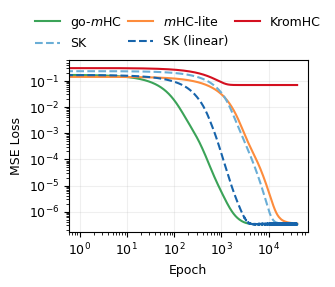

In [ ]:
import matplotlib.pyplot as plt

col_width = 3.25

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.5,
    "figure.figsize": (col_width, col_width * 0.75),
    "grid.alpha": 0.3
})

fig, ax = plt.subplots()

plot_order = ['go-$m$HC ($s=2$, Q)', '$m$HC-lite', 'KromHC', 'Sinkhorn-Knopp', 'Sinkhorn-Knopp Linear']
legend_labels = [r'go-$m$HC', r'$m$HC-lite', 'KromHC', 'SK', 'SK (linear)']
legend_colors = [plt.cm.YlGn(1.3/2), *plt.cm.YlOrRd([0.5, 0.8]), plt.cm.Blues(0.5), plt.cm.Blues(0.8)]
linestyles = ['-'] * 3 + ['--']*2

for name, color, label, linestyle in zip(plot_order, legend_colors, legend_labels, linestyles):
    ax.plot(test[name].T.mean(axis=1), color=color, label=label, linestyle=linestyle)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')

ax.grid(True, which="both", ls="-", alpha=0.2)
ax.grid(False, which="minor")

handles, labels = ax.get_legend_handles_labels()
new_order = [0, 3, 1, 4, 2]

plt.tight_layout()
ax.legend([handles[i] for i in new_order], [labels[i] for i in new_order], frameon=False, ncol=3, columnspacing=0.5, loc='upper right', bbox_to_anchor=(1.1, 1.33))

plt.savefig('loss_comparison_with_SK.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

In [ ]:
@dataclass
class ConfigSweep():
    n: list
    noise_mag: list = field(default_factory=lambda: [1e-4])
    B: list = field(default_factory=lambda: [64])
    lr: list = field(default_factory=lambda: [0.001])
    sparsity: list = field(default_factory=lambda: [0.0])
    num_epochs: list = field(default_factory=lambda: [10_000])
    dataset_size: list = field(default_factory=lambda: [100])
    seed: list = field(default_factory=lambda: [42])
    models_to_run: list = field(default_factory=lambda: (go_mHC_run(s=2), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2)))
    toy_model_type: type = DatasetModel
    random_target_generator: callable = generate_birkhoff_using_SK
    
    def __getitem__(self, idx):
        if isinstance(idx, str):
            return getattr(self, idx)
        else:
            raise KeyError("ConfigSweep only supports string keys corresponding to its fields.")
    
def run_experiment_sweep(config_sweep: ConfigSweep, double_tqdm=False):
    keys = ['n', 'B', 'lr', 'sparsity', 'num_epochs', 'dataset_size', 'noise_mag', 'seed']
    values = [getattr(config_sweep, key) for key in keys]
    
    all_combinations = list(itertools.product(*values))
    
    print(f"Running {len(all_combinations)} experiments...")
    
    results = []
    
    for idx, combination in tqdm.tqdm(enumerate(all_combinations), disable=not double_tqdm):
        print(f"Running experiment {idx + 1}/{len(all_combinations)}")
        config_dict = dict(zip(keys, combination))
        config = Config(**config_dict, models_to_run=config_sweep.models_to_run, toy_model_type=config_sweep.toy_model_type, random_target_generator=config_sweep.random_target_generator)
        summary, history = run_single_experiment(config, show_tqdm=double_tqdm)
        results.append((config_dict, summary, history))
    
    return results

# Loss Trajectories by # of residual streams and sparsity

In [11]:
# Takes 36mins on MBP 2021 - M1 Pro
sweep_config = ConfigSweep(
    n=[2, 3, 4, 5, 6, 7, 8, 10, 12, 16],
    sparsity=[0, 0.5, 0.9],
    num_epochs=[10_000],
    noise_mag=[1e-1],
    models_to_run=(go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4))
)

results = run_experiment_sweep(sweep_config)

Running 30 experiments...
Running experiment 1/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 2/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 3/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 4/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 5/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 6/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 7/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 8/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 9/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 10/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 11/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 12/30
Loading result from cache file: toy_model_cache.pkl
Running experiment 13/30
Loading result from cache file: to

Noise 0.1: GU_s2 shape = (0,)


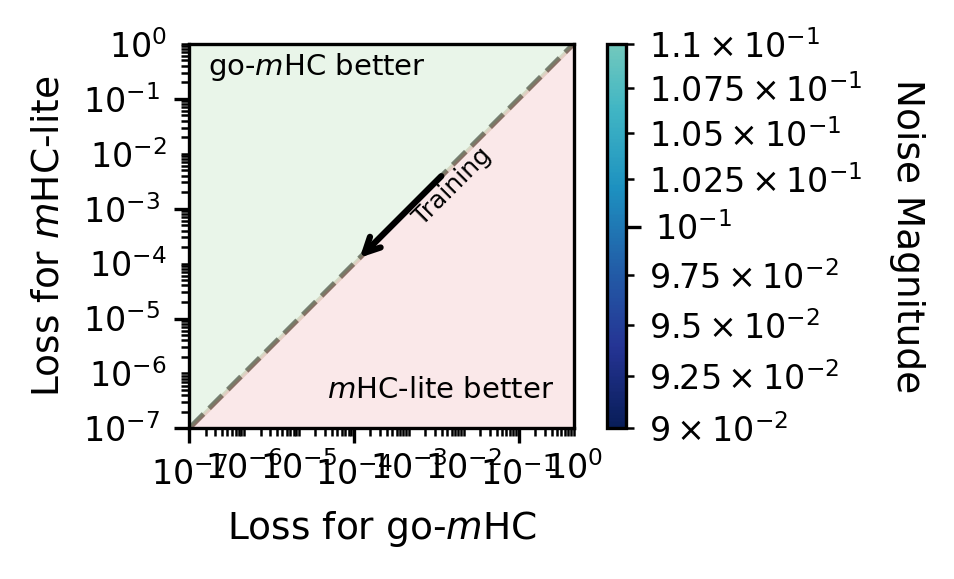

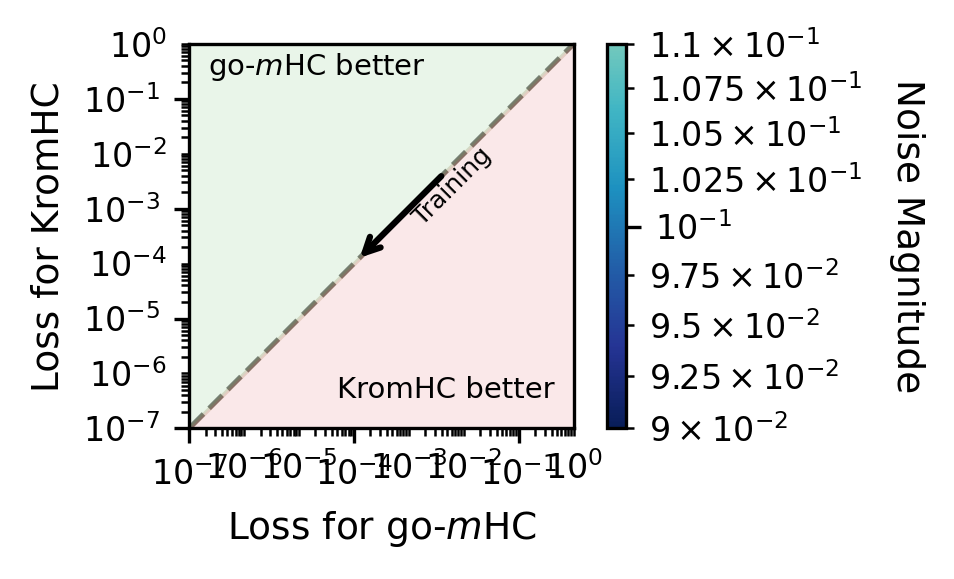

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator

plt.rcParams.update({
    "text.usetex": False,            
    "font.size": 9,                 
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True       
})

dsource = {}
for config, summary, history in results:
    nm = config['noise_mag']
    if nm not in dsource:
        dsource[nm] = {}
    
    for key_name, history_key in [("GU_s2", "gu_2"), ("MHC_lite", "mhc_lite"), ("KromHC", "kromhc")]:
        data = history.get(history_key, [])
        
        if len(data) > 0:
            dsource[nm][key_name] = np.mean(np.array(data), axis=0)
        else:
            dsource[nm][key_name] = np.array([]) 

for nm in dsource:
    print(f"Noise {nm}: GU_s2 shape = {np.shape(dsource[nm]['GU_s2'])}")
additional_details = False

for title, method_key in zip(["$m$HC-lite", "KromHC"], ["MHC_lite", "KromHC"]):
    plt.figure(figsize=(3.25, 2.0), dpi=300)
    
    noise_keys = sorted(dsource.keys())
    norm = mcolors.LogNorm(vmin=min(noise_keys), vmax=max(noise_keys))
    
    base_cmap = cm.YlGnBu_r
    num_colors = 256
    colormap = mcolors.ListedColormap(base_cmap(np.linspace(0.0, 0.6, num_colors)))

    for noise in noise_keys:
        color = colormap(norm(noise))
        
        subsample = 5
        gu_data = dsource[noise]["GU_s2"][::subsample]
        method_data = dsource[noise][method_key][::subsample]
        
        if len(gu_data) == 0 or len(method_data) == 0:
            continue

        plt.scatter(
            gu_data,
            method_data, 
            marker='o', 
            color=color,
            alpha=1,
            s=4,
            rasterized=True
        )

    sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([]) 
    
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('Noise Magnitude', rotation=270, labelpad=15)
    
    plt.yscale('log')
    plt.xscale('log')
    
    plt.plot([1e-8, 2], [1e-8, 2], 'k--', alpha=0.5, zorder=-2) 
    
    x_space = np.logspace(-8, 1, 100)
    plt.fill_between(x_space, 10, x_space, color='tab:green', alpha=0.1, zorder=0)
    plt.fill_between(x_space, x_space, 1e-9, color='tab:red', alpha=0.1, zorder=0)
    
    plt.annotate('', xy=(1e-4, 1e-4), xytext=(5e-3, 5e-3), 
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    plt.text(1e-3, 5e-4, 'Training', fontsize=6, rotation=45)
    
    plt.gca().text(0.05, 0.92, 'go-$m$HC better', transform=plt.gca().transAxes, fontsize=7)
    plt.gca().text(0.95, 0.08, f'{title} better', transform=plt.gca().transAxes, 
                   fontsize=7, ha='right')

    plt.xlim(1e-7, 1)
    plt.ylim(1e-7, 1)
    plt.gca().set_aspect('equal')
    
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0), numticks=10))
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0), numticks=10))

    plt.xlabel("Loss for go-$m$HC")
    plt.ylabel(f"Loss for {title}")
    
    plt.show()

/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


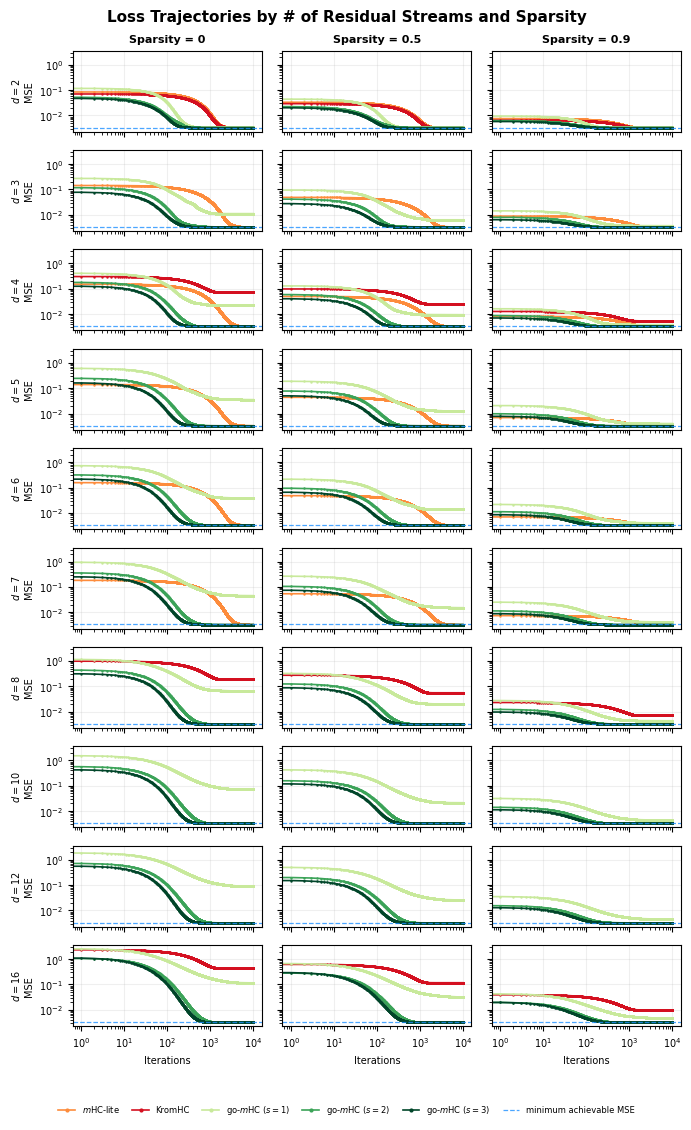

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH * 2, COLUMN_WIDTH * 3.25)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.2,
    "figure.autolayout": False
})


results_lookup = {(c['n'], c['sparsity']): h for c, s, h in results}

n_values = sorted(list(set(c['n'] for c, s, h in results)))
sparsity_values = sorted(list(set(c['sparsity'] for c, s, h in results)))

first_config = results[0][0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3)), "dodgerblue"]

n_rows = len(n_values)
n_cols = len(sparsity_values)

fig, axes = plt.subplots(n_rows, n_cols, figsize=FIG_SIZE, sharex=True, sharey=True)

if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = axes[np.newaxis, :]
elif n_cols == 1:
    axes = axes[:, np.newaxis]

for col, s in enumerate(sparsity_values):
    axes[0, col].set_title(f"Sparsity = {s}", fontsize=8, fontweight='bold')

for row, d in enumerate(n_values):
    for col, s in enumerate(sparsity_values):
        ax = axes[row, col]
        
        history = results_lookup.get((d, s), {})

        histories = {
            '$m$HC-lite': [],
            'KromHC': [],
            ' ': [],
            'go-$m$HC ($s=1$)': history.get('go-$m$HC ($s=1$, Q)', []),
            'go-$m$HC ($s=2$)': history.get('go-$m$HC ($s=2$, Q)', []),
            'go-$m$HC ($s=3$)': history.get('go-$m$HC ($s=3$, Q)', []),
        }
        
        if 'KromHC' in history:
            histories['KromHC'] = history.get('KromHC', [])
            
        if '$m$HC-lite' in history:
            histories['$m$HC-lite'] = history.get('$m$HC-lite', [])

        i = 0
        for label in histories:
            data = histories[label]
            avg_data = np.mean(data, axis=0)
            ax.plot(avg_data, color=colors[i],
                    alpha=0 if label == " " else 1,
                    marker='.', markersize=1.5, rasterized=True)
            i += 1

        ax.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8)

        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.grid(True, which="major", ls="-", alpha=0.2)

        if col == 0:
            ax.set_ylabel(f"$d={d}$\nMSE", fontsize=7)
        if row == n_rows - 1:
            ax.set_xlabel("Iterations", fontsize=7)

legend_labels = ['$m$HC-lite', 'KromHC', 'go-$m$HC ($s=1$)',
                 'go-$m$HC ($s=2$)', 'go-$m$HC ($s=3$)', 'minimum achievable MSE']
legend_colors = [colors[0], colors[1], colors[3], colors[4], colors[5]]

handles = [Line2D([0], [0], color=c, marker='.', markersize=4, lw=1.2, label=l)
           for c, l in zip(legend_colors, legend_labels[:-1])]

handles.append(Line2D([0], [0], color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8,
                       label='minimum achievable MSE'))

fig.legend(handles=handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.01),
           ncol=len(handles),
           frameon=False,
           fontsize=6,
           columnspacing=1.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])

fig.suptitle("Loss Trajectories by # of Residual Streams and Sparsity",
             fontsize=11, fontweight='bold', y=0.97)

plt.savefig('loss_traj_sparsity_grid.pdf', bbox_inches='tight', dpi=300)
plt.show()

# MSE by matrix dimension

In [391]:
sweep_config = ConfigSweep(
    n=[2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16],
    sparsity=[0],
    num_epochs=[10_000],
    noise_mag=[1e-1],
    models_to_run=(go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4))
)

results = run_experiment_sweep(sweep_config)

Running 11 experiments...
Running experiment 1/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 2/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 3/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 4/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 5/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 6/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 7/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 8/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 9/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 10/11
True
Loading result from cache file: toy_model_cache.pkl
Running experiment 11/11
True
Loading result from cache file: toy_model_cache.pkl


noise_floor 0.003333333333333334


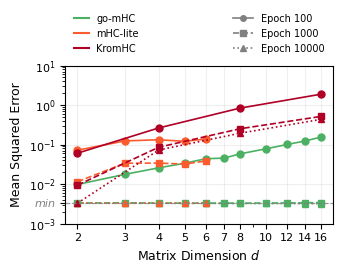

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.8)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True
})

first_config = results[0][0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
dims = sorted(list(set(c['n'] for c, s, h in results)))

print("noise_floor", noise_floor)

colors_methods = {
    'go-mHC': plt.cm.YlGn(0.6),
    'mHC-lite': plt.cm.YlOrRd(0.6),
    'KromHC': plt.cm.YlOrRd(0.9),
}
epoch_indices = [99, 999, 9999]
epoch_markers = {99: 'o', 999: 's', 9999: '^'}
epoch_linestyles = {99: '-', 999: '--', 9999: ':'}

def get_loss_at_epoch(avg_history, epoch_idx):
    if avg_history is None or len(avg_history) == 0:
        return None
    if epoch_idx >= len(avg_history):
        return avg_history[-1] # Return last available if index is out of bounds
    return avg_history[epoch_idx]

fig, ax = plt.subplots(figsize=FIG_SIZE)

method_map = {
    'go-mHC': 'go-$m$HC ($s=2$, Q)',
    'mHC-lite': '$m$HC-lite',
    'KromHC': 'KromHC'
}

for method_name, history_key in method_map.items():
    color = colors_methods[method_name]
    
    for epoch in epoch_indices:
        xs = []
        ys = []
        
        for d in dims:
            # Find the history for this specific dimension d
            # (Assuming sparsity/other params are constant for this specific plot)
            current_hist = None
            for config, summary, history in results:
                if config['n'] == d:
                    current_hist = history.get(history_key)
                    break
            
            if current_hist is None or len(current_hist) == 0:
                continue
                
            # Filter logic from original code
            if method_name == 'KromHC' and d.bit_count() != 1:
                continue
            if method_name == 'mHC-lite' and d >= 7:
                continue
                
            avg_hist = np.mean(current_hist, axis=0)
            val = get_loss_at_epoch(avg_hist, epoch)
            
            if val is not None:
                xs.append(d)
                ys.append(val)
        
        if xs:
            ax.plot(xs, ys,
                    color=color,
                    marker=epoch_markers[epoch],
                    linestyle=epoch_linestyles[epoch],
                    markersize=5,
                    rasterized=True)

ax.axhline(y=noise_floor, color='gray', linestyle='--', linewidth=0.9, alpha=0.8)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xticks(dims)
ax.set_xticklabels([str(d) for d in dims])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_ylim(1e-3, 1e1)
plt.draw() 

existing_ticks = ax.get_yticks()
# Filter ticks to keep them within a reasonable range and add noise floor
new_ticks = np.unique(np.append(existing_ticks[(existing_ticks >= 1e-3) & (existing_ticks <= 1e1)], noise_floor))
new_ticks.sort()

# Create labels manually to handle 'min'
new_labels = []
for t in new_ticks:
    if np.isclose(t, noise_floor):
        new_labels.append('min')
    else:
        new_labels.append(f'$10^{{{int(np.log10(t))}}}$' if t > 0 else '0')

ax.set_yticks(new_ticks)
ax.set_yticklabels(new_labels)

# Style the "min" tick label distinctively
for tick_label in ax.get_yticklabels():
    if tick_label.get_text() == 'min':
        tick_label.set_color('gray')
        tick_label.set_fontstyle('italic')

ax.set_xlabel("Matrix Dimension $d$")
ax.set_ylabel("Mean Squared Error")
ax.grid(True, which="major", ls="-", alpha=0.2)

# Two-column legend above the plot
method_handles = [
    Line2D([0], [0], color=colors_methods[m], lw=1.5, label=m)
    for m in ['go-mHC', 'mHC-lite', 'KromHC']
]
epoch_handles = [
    Line2D([0], [0], color='gray', marker=epoch_markers[e],
           linestyle=epoch_linestyles[e], lw=1.2, markersize=4, label=f'Epoch {e+1}')
    for e in epoch_indices
]

legend1 = ax.legend(handles=method_handles,
                    loc='lower left',
                    bbox_to_anchor=(0.0, 1.02),
                    ncol=1, frameon=False, fontsize=7,
                    handlelength=1.5)
legend2 = ax.legend(handles=epoch_handles,
                    loc='lower right',
                    bbox_to_anchor=(1.0, 1.02),
                    ncol=1, frameon=False, fontsize=7,
                    handlelength=2.0)
ax.add_artist(legend1)

plt.savefig('mse_vs_dim_high_noise.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Time to convergence by matrix dimension

In [ ]:
sweep_config = ConfigSweep(
    n=(np.unique(np.array(2**np.linspace(1, 6, 21), dtype=int))),
    sparsity=[0],
    num_epochs=[10_000],
    noise_mag=[1e-1],
    models_to_run=(go_mHC_run(s=2), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2))#, KromHC_run(ik=4))
    # models_to_run=(go_mHC_run(s=1), go_mHC_run(s=2), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4))
)

results = run_experiment_sweep(sweep_config)

Running 18 experiments...
Running experiment 1/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 2/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 3/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 4/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 5/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 6/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 7/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 8/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 9/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 10/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 11/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 12/18
Loading result from cache file: toy_model_cache.pkl
Running experiment 13/18
Loading result from cache file: to

<>:80: SyntaxWarning: invalid escape sequence '\;'
<>:80: SyntaxWarning: invalid escape sequence '\;'
/var/folders/fp/ywrwxn_122s537c0sm16gcxm0000gn/T/ipykernel_4729/3875517165.py:80: SyntaxWarning: invalid escape sequence '\;'
  ax_zoom.set_title(f"$\;\;d={target_d}$", fontsize=7, pad=2, loc='left')


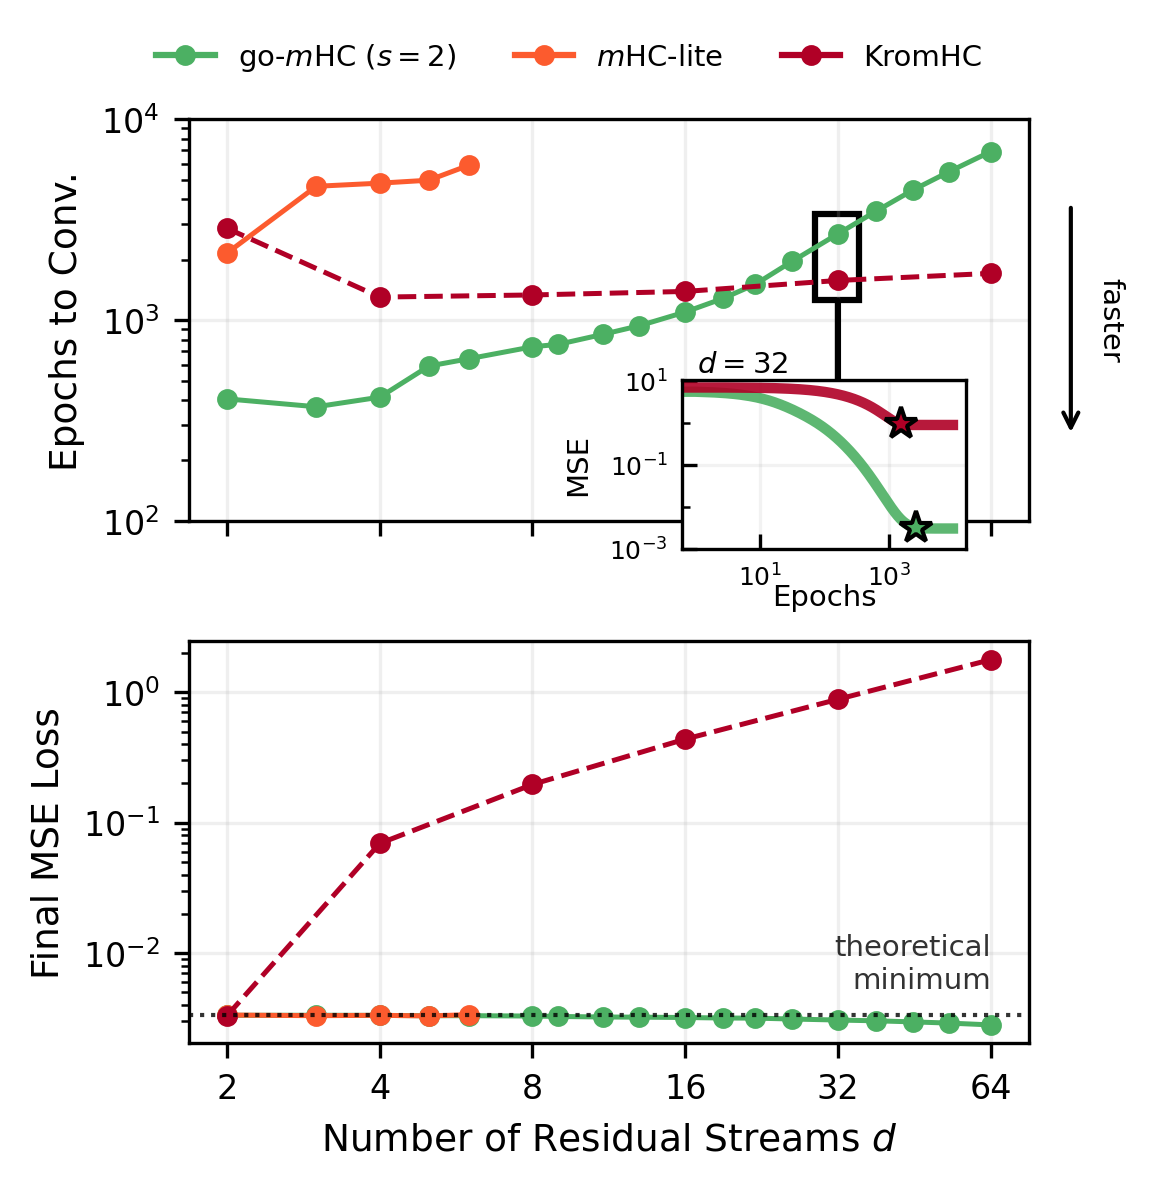

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 1.1)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": False
})

def get_convergence_epoch(history_list, threshold_frac=0.05):
    if history_list is None or np.size(history_list) == 0:
        return None
    final_loss = history_list[-1]
    cutoff = final_loss * (1 + threshold_frac)
    indices = np.where(history_list <= cutoff)[0]
    return indices[0] if indices.size > 0 else None

def plot_trajectories_in_zoom(ax_zoom, results, target_d):
    """
    Plots the specific loss trajectories for a dimension target_d 
    into the provided axis_zoom.
    """
    experiment_data = next((h for c, s, h in results if c['n'] == target_d), None)
    if experiment_data is None: return

    methods = [
        ('go-mHC', 'go-$m$HC ($s=2$, Q)', lambda d: False),
        ('mHC-lite', '$m$HC-lite', lambda d: d >= 7),
        ('KromHC', 'KromHC', lambda d: d.bit_count() != 1),
    ]

    for method_name, method_key, skip_fn in methods:
        if skip_fn(target_d): continue
        hist = np.array(experiment_data.get(method_key, []))
        if hist.size == 0: continue

        avg_hist = np.mean(hist, axis=0)
        color = colors_methods.get(method_name, 'black')
        ax_zoom.plot(avg_hist, color=color, linewidth=2.5, alpha=0.9)
        
        # Add convergence marker
        conv_epochs = [get_convergence_epoch(h) for h in hist]
        avg_conv = np.mean([c for c in conv_epochs if c is not None])
        if not np.isnan(avg_conv):
            ax_zoom.plot(avg_conv, avg_hist[int(avg_conv)], marker='*', markersize=8, color=color, markeredgecolor='k', markeredgewidth=1)

    ax_zoom.tick_params(
        axis='both',
        which='both',
        direction='in',
        colors='black',
        grid_color='gray',
        grid_alpha=0.5
    )

    ax_zoom.set_yscale('log')
    ax_zoom.set_xscale('log')
    ax_zoom.set_xlabel("Epochs", fontsize=7)

    ax_zoom.xaxis.set_label_coords(0.5, -0.2)
    ax_zoom.set_ylabel("MSE", fontsize=7)
    ax_zoom.tick_params(axis='both', which='both', labelsize=6)

    ax_zoom.set_xticks([], minor=True)
    ax_zoom.set_yticks([0.001, 0.1, 10], minor=False)
    ax_zoom.set_yticks([0.001, 0.01, 0.1, 1, 10], minor=True, labels=[])
    
    ax_zoom.set_title(f"$\;\;d={target_d}$", fontsize=7, pad=2, loc='left')
    ax_zoom.grid(True, which="major", ls="-", alpha=0.1)

first_config = results[0][0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
dims = sorted(list(set(c['n'] for c, s, h in results)))

colors_methods = {
    'go-mHC': plt.cm.YlGn(0.6),
    'mHC-lite': plt.cm.YlOrRd(0.6),
    'KromHC': plt.cm.YlOrRd(0.9),
    'KromHC (higher loss)': plt.cm.YlOrRd(0.9)
}

method_map = [
    ('go-mHC', 'go-$m$HC ($s=2$, Q)'),
    ('mHC-lite', '$m$HC-lite'),
    ('KromHC', 'KromHC'),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIG_SIZE, sharex=True, dpi=300)
plt.subplots_adjust(hspace=0.3, left=0.15, right=0.95, top=0.9, bottom=0.1)

fig.canvas.draw()
p1 = ax1.get_position()
p2 = ax2.get_position()


z_left = p1.x0 + (p1.width / 2.0) * 1.2 + 0.1 - 0.03 - 0.08
z_bottom = p2.y1 + 0.08
z_width = p1.x1 - z_left + 0.05 - 0.03 - 0.08
z_height = (p1.y0 + p1.height/2.0 * 0.7) - z_bottom

axis_zoom = fig.add_axes([z_left, z_bottom, z_width, z_height])

draw_box_around_d = 32
box_coordinates = []

for method_name, history_key in method_map:
    color = colors_methods[method_name]
    xs, ys_conv, ys_loss, reached_floor = [], [], [], []

    for d in dims:
        hist = next((h.get(history_key, []) for c, s, h in results if c['n'] == d), [])
        if 'KromHC' in method_name and d.bit_count() != 1: continue
        if method_name == 'mHC-lite' and d >= 7: continue
        if np.size(hist) == 0: continue

        conv_list = [get_convergence_epoch(h) for h in hist if get_convergence_epoch(h) is not None]
        avg_conv = np.mean(conv_list) if conv_list else None
        final_loss = np.mean(np.min(hist, axis=1)) if len(hist) > 0 else None
        
        if d == draw_box_around_d:
            box_coordinates.append((avg_conv, final_loss))
        
        if avg_conv and final_loss:
            xs.append(d)
            ys_conv.append(avg_conv)
            ys_loss.append(final_loss)
            reached_floor.append(final_loss <= noise_floor * 1.05)

    if xs:
        ls = '-' if all(reached_floor) else '--'
        ax1.plot(xs, ys_conv, color=color, marker='o', ls=ls, markersize=4)
        ax2.plot(xs, ys_loss, color=color, marker='o', ls=ls, markersize=4)

plot_trajectories_in_zoom(axis_zoom, results, target_d=draw_box_around_d)

# draw a box around the zoomed point in the main plot, yspan should include all points
if box_coordinates:
    conv_val, loss_val = box_coordinates[0]
    conv_val_2, loss_val_2 = box_coordinates[1]
    rect = plt.Rectangle((draw_box_around_d * 0.9, min(conv_val, conv_val_2) * 0.8),
                         draw_box_around_d * 0.2,
                         max(conv_val, conv_val_2) * 1.25 - min(conv_val, conv_val_2) * 0.8,
                         linewidth=1.5, edgecolor='k', facecolor='none', linestyle='-')
    ax1.add_patch(rect)
    
    ax1.set_ylim(1e2, 10**4)
    
    
    ax1.annotate('', xy=(draw_box_around_d, min(conv_val, conv_val_2)/1.15), xytext=(draw_box_around_d, 1e2),
                    arrowprops=dict(arrowstyle='-', color='k', lw=1.5), annotation_clip=False)

ax1.set_yscale('log')
ax1.set_ylabel("Epochs to Conv.")
ax1.grid(True, which="major", ls="-", alpha=0.2)

ax2.axhline(y=noise_floor, color='k', linestyle=':', linewidth=1.0, alpha=0.8)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_ylabel("Final MSE Loss")
ax2.set_xlabel("Number of Residual Streams $d$")
ax2.grid(True, which="major", ls="-", alpha=0.2)

tick_vals = [2**i for i in range(1, int(np.log2(max(dims))) + 1)]
ax2.set_xticks(tick_vals)
ax2.set_xticklabels([str(v) for v in tick_vals])
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())


ax1.set_xticks([], minor=True)
ax2.set_xticks([], minor=True)


ax1.annotate('', xy=(1.05, 0.2), xytext=(1.05, 0.8), xycoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.0), annotation_clip=False)
ax1.annotate('faster', xy=(1.08, 0.5), xycoords='axes fraction', fontsize=7,
             va='center', rotation=270, annotation_clip=False)

ax2.text(max(dims), noise_floor*2.5, 'theoretical\nminimum', va='center', ha='right', fontsize=7, color='k', alpha=0.8)


legend_handles = [Line2D([0], [0], color=colors_methods[m], lw=1.5, marker='o', markersize=4, label=n.replace(", Q", "")) 
                 for m, n in method_map]
ax1.legend(handles=legend_handles, loc='lower left', bbox_to_anchor=(-0.07, 1.05),
           ncol=3, frameon=False, fontsize=7)

plt.savefig('final_convergence_vs_dim.pdf', bbox_inches='tight', dpi=300)
plt.show()

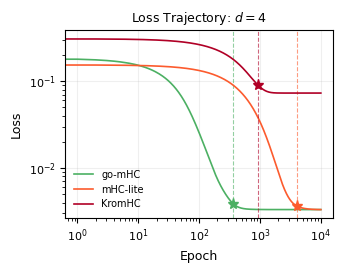

In [ ]:
def plot_loss_trajectory(d):
    """
    Plot loss trajectories for all models at a given matrix dimension d.
    Now uses the 'results' list from run_experiment_sweep.
    """
    # Find the specific experiment in results that matches dimension d
    experiment_data = None
    for config, summary, history in results:
        if config['n'] == d:
            experiment_data = history
            break
    
    if experiment_data is None:
        print(f"No experiment found for dimension d={d}")
        return

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    # Configuration for methods
    methods = [
        ('go-mHC', 'go-$m$HC ($s=2$, Q)', lambda d: False),
        ('mHC-lite', '$m$HC-lite', lambda d: d >= 7),
        ('KromHC', 'KromHC', lambda d: d.bit_count() != 1),
    ]

    for method_name, method_key, skip_fn in methods:
        if skip_fn(d):
            continue
            
        hist = experiment_data.get(method_key, [])
        
        if hist is None or len(hist) == 0:
            continue

        hist = np.array(hist)
        avg_hist = np.mean(hist, axis=0)
        num_epochs = avg_hist.shape[0]

        color = colors_methods.get(method_name, 'black')
        
        ax.plot(range(num_epochs), avg_hist, color=color, label=method_name, linewidth=1.2)

        conv_vals = []
        for single_hist in hist:
            conv = get_convergence_epoch(single_hist)
            if conv is not None:
                conv_vals.append(conv)
        
        if conv_vals:
            avg_conv = np.mean(conv_vals)
            avg_conv_int = int(avg_conv)
            
            ax.axvline(x=avg_conv, color=color, linestyle='--', linewidth=0.8, alpha=0.6)
            
            if avg_conv_int < len(avg_hist):
                ax.plot(avg_conv, avg_hist[avg_conv_int], 
                        marker='*', color=color, markersize=8, zorder=5)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Loss Trajectory: $d = {d}$", fontsize=9)
    ax.grid(True, which="major", ls="-", alpha=0.2)
    ax.legend(frameon=False, fontsize=7)
    
    plt.tight_layout()
    plt.savefig(f'convergence_loss_trajectory_d_{d}.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Example usage:
# Simply pass the dimension 'd' you want to see. 
# The function will find it in the 'results' list automatically.
plot_loss_trajectory(d=4)

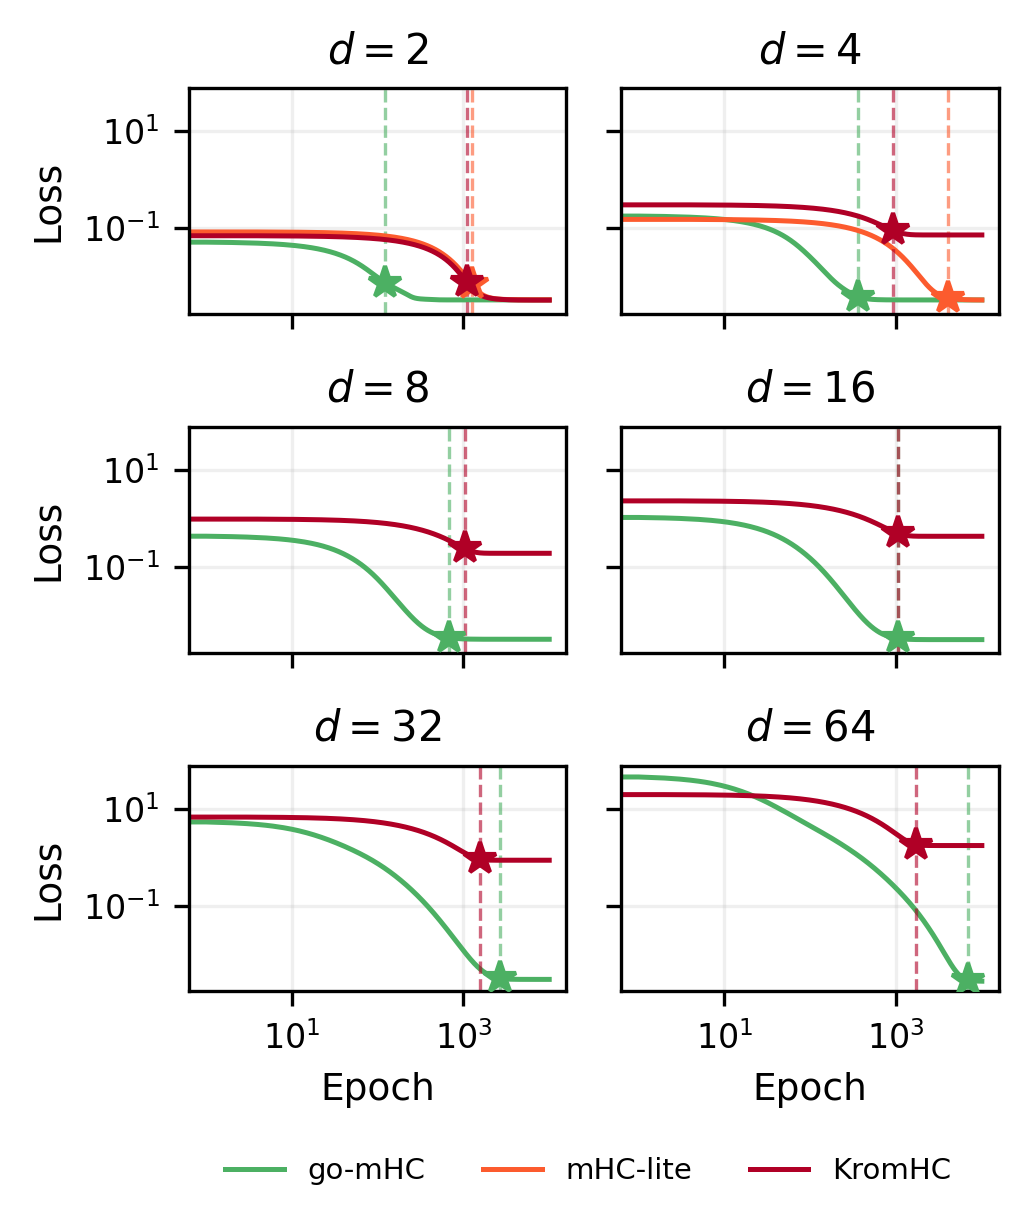

In [631]:
import matplotlib.pyplot as plt
import numpy as np

colors_methods = {
    'go-mHC': plt.cm.YlGn(0.6),
    'mHC-lite': plt.cm.YlOrRd(0.6),
    'KromHC (higher loss)': plt.cm.YlOrRd(0.9),
    'KromHC': plt.cm.YlOrRd(0.9)
}

def plot_loss_trajectory_subplot(d, ax):
    """
    Plots the loss trajectory for a specific d onto a provided matplotlib axis.
    """
    # Find the specific experiment in results
    experiment_data = None
    for config, summary, history in results:
        if config['n'] == d:
            experiment_data = history
            break
    
    if experiment_data is None:
        ax.set_title(f"No data for d={d}")
        return

    # Configuration for methods
    methods = [
        ('go-mHC', 'go-$m$HC ($s=2$, Q)', lambda d: False),
        ('mHC-lite', '$m$HC-lite', lambda d: d >= 7),
        ('KromHC', 'KromHC', lambda d: d.bit_count() != 1),
    ]

    for method_name, method_key, skip_fn in methods:
        if skip_fn(d):
            continue
            
        hist = experiment_data.get(method_key, [])
        if hist is None or len(hist) == 0:
            continue

        hist = np.array(hist)
        avg_hist = np.mean(hist, axis=0)
        num_epochs = avg_hist.shape[0]
        color = colors_methods[method_name]
        
        # Plot average trajectory
        ax.plot(range(num_epochs), avg_hist, color=color, label=method_name, linewidth=1.2)

        # Convergence logic
        conv_vals = [get_convergence_epoch(h) for h in hist if get_convergence_epoch(h) is not None]
        
        if conv_vals:
            avg_conv = np.mean(conv_vals)
            idx = min(int(avg_conv), len(avg_hist) - 1)
            ax.axvline(x=avg_conv, color=color, linestyle='--', linewidth=0.8, alpha=0.6)
            ax.plot(avg_conv, avg_hist[idx], marker='*', color=color, markersize=8, zorder=5)

    # Formatting for the subplot
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(f"$d = {d}$", fontsize=10)
    ax.grid(True, which="major", ls="-", alpha=0.2)
    
    # Only show labels on the outer edges to save space
    ax.tick_params(axis='both', which='major', labelsize=8)

# --- Grid Generation ---
dimensions = [2, 4, 8, 16, 32, 64]
fig, axes = plt.subplots(3, 2, figsize=(COLUMN_WIDTH, COLUMN_WIDTH * 1.2), sharex=True, sharey=True, dpi=300)
axes_flat = axes.flatten()

for i, d in enumerate(dimensions):
    plot_loss_trajectory_subplot(d, axes_flat[i])
    # Add labels only to specific plots to keep it clean
    if i >= 4: axes_flat[i].set_xlabel("Epoch")
    if i % 2 == 0: axes_flat[i].set_ylabel("Loss")
    
    # if d == 4:
    #     for spine in axes_flat[i].spines.values():
    #         spine.set_linewidth(2.0)
    #         spine.set_edgecolor('blue') # Makes it very obvious
    #         spine.set_zorder(10)       # Ensures the border stays on top

# Add a single legend for the entire figure at the bottom
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.57, -0.02))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.suptitle("Loss Trajectories across Dimensions", fontsize=14, y=0.98)
plt.savefig('convergence_indiv_loss_trajectory.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Loss Trajectories by # of residual streams

In [395]:
# same as previous cell, using new code
sweep_config = ConfigSweep(
    n=[2, 3, 4, 5, 6, 8, 10, 12, 14, 16],
    noise_mag=[1e-1],
    num_epochs=[10_000],
    models_to_run=(go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), mHC_lite_run(max_safe_d=7), KromHC_run(ik=2), KromHC_run(ik=4)) #[go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), KromHC_run(), mHC_lite_run()],
)

# all_results, all_histories
results = run_experiment_sweep(sweep_config, double_tqdm=True)

Running 10 experiments...


0it [00:00, ?it/s]

Running experiment 1/10
True
Loading result from cache file: toy_model_cache.pkl


1it [00:00,  2.02it/s]

Running experiment 2/10
True
Loading result from cache file: toy_model_cache.pkl


...

8it [00:02,  4.01it/s]

Running experiment 9/10
True
Loading result from cache file: toy_model_cache.pkl


9it [00:02,  4.01it/s]

Running experiment 10/10
True
Loading result from cache file: toy_model_cache.pkl


10it [00:02,  3.68it/s]


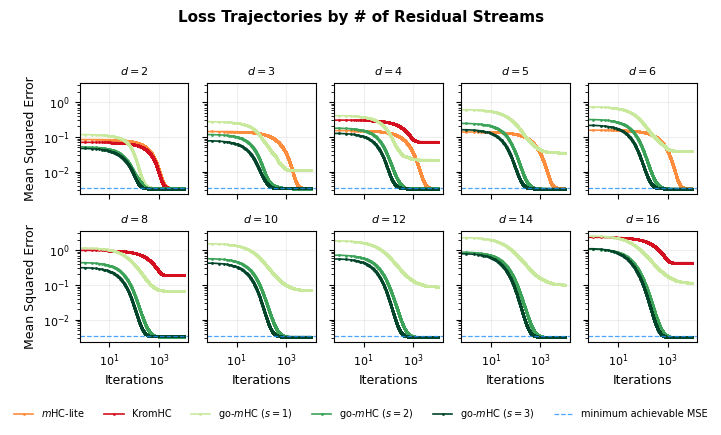

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


COLUMN_WIDTH = 3.5

FIG_SIZE = (COLUMN_WIDTH * 2, COLUMN_WIDTH * 1.2)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": False
})


first_config, _, _ = results[0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3))]

# Create the 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=FIG_SIZE, sharex=True, sharey=True)
axes_flat = axes.flatten()

fig.suptitle("Loss Trajectories by # of Residual Streams", fontsize=11, fontweight='bold')

for idx, (config_dict, summary, history) in enumerate(results):
    if idx >= len(axes_flat):
        break
        
    ax = axes_flat[idx]
    n_val = config_dict['n']

    plot_data_map = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': history.get('go-$m$HC ($s=1$, Q)', []),
        'go-$m$HC ($s=2$)': history.get('go-$m$HC ($s=2$, Q)', []),
        'go-$m$HC ($s=3$)': history.get('go-$m$HC ($s=3$, Q)', [])
    }
    
    if n_val.bit_count() == 1:
        plot_data_map['KromHC'] = history.get('KromHC', [])
    if n_val < 7:
        plot_data_map['$m$HC-lite'] = history.get('$m$HC-lite', [])

    for i, (label, data) in enumerate(plot_data_map.items()):
        avg_data = np.mean(data, axis=0)
        ax.plot(avg_data, 
                label=label, 
                color=colors[i],
                alpha=0 if label == " " else 1, 
                marker='.', 
                markersize=2, 
                rasterized=True)

    ax.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(f"$d={n_val}$", fontsize=8)
    ax.grid(True, which="major", ls="-", alpha=0.2)

    # Label only the outer plots
    if idx >= 5: # Bottom row
        ax.set_xlabel("Iterations")
    if idx % 5 == 0: # Left column
        ax.set_ylabel("Mean Squared Error")

# Extract handles from one of the populated axes
handles, labels = ax.get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l.strip()]

filtered.append((
    Line2D([0], [0], color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8),
    'minimum achievable MSE'
))

fig.legend(*zip(*filtered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=len(filtered),
           frameon=False,
           fontsize=7,
           columnspacing=2)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('appendix_loss_trajectories_by_residual_streams.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Single Loss Curve

In [397]:
# same as previous cell, using new code
sweep_config = ConfigSweep(
    n=[4],
    noise_mag=[1e-1],
    num_epochs=[10_000],
    models_to_run=[go_mHC_run(s=1), go_mHC_run(s=2), go_mHC_run(s=3), KromHC_run(), mHC_lite_run()],
)

# all_results, all_histories
results = run_experiment_sweep(sweep_config, double_tqdm=True)

Running 1 experiments...


0it [00:00, ?it/s]

Running experiment 1/1
True
Loading result from cache file: toy_model_cache.pkl


1it [00:00,  3.33it/s]


/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


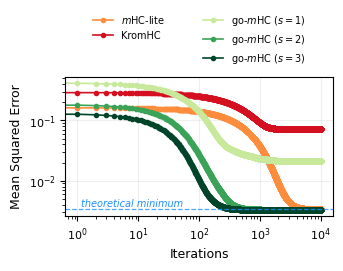

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

COLUMN_WIDTH = 3.5  
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.8)

plt.rcParams.update({
    "text.usetex": False,            
    "font.size": 9,                 
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True       
})

first_config, _, _ = results[0]
noise_floor = (first_config['noise_mag'] ** 2) / 3

# Define colors
colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3))]

# Iterate through each experiment result
for i, (config_dict, summary, history) in enumerate(results):
    plt.figure(figsize=FIG_SIZE)
    
    plot_data_map = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': history.get('go-$m$HC ($s=1$, Q)', []),
        'go-$m$HC ($s=2$)': history.get('go-$m$HC ($s=2$, Q)', []),
        'go-$m$HC ($s=3$)': history.get('go-$m$HC ($s=3$, Q)', [])
    }
    
    n_val = config_dict['n']
    
    if n_val.bit_count() == 1:
        plot_data_map['KromHC'] = history.get('KromHC', [])

    if n_val < 7:
        plot_data_map['$m$HC-lite'] = history.get('$m$HC-lite', [])

    for color_idx, (label, data) in enumerate(plot_data_map.items()):
        avg_data = np.mean(data, axis=0)
        
        plt.plot(avg_data, 
                    label=label, 
                    color=colors[color_idx],
                    alpha=0 if label == " " else 1, 
                    marker='.', 
                    rasterized=True)

    plt.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.9, alpha=0.8)

    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Iterations")
    plt.ylabel("Mean Squared Error")
    plt.grid(True, which="major", ls="-", alpha=0.2)

    ax = plt.gca()
    ax.annotate('theoretical minimum', 
                xy=(0.46, noise_floor - 0.0005), 
                xycoords=('axes fraction', 'data'),
                xytext=(-4, 4), 
                textcoords='offset points',
                ha='right', 
                va='bottom',
                color='dodgerblue', 
                fontstyle='italic', 
                fontsize=7)

    plt.legend(loc='lower center', 
               bbox_to_anchor=(0.5, 1.02), 
               ncol=2, 
               frameon=False, 
               fontsize=7, 
               columnspacing=4)

    plt.show()

# Try different generated target matrix methods

True
Loading result from cache file: toy_model_cache.pkl
True
Loading result from cache file: toy_model_cache.pkl
True
Loading result from cache file: toy_model_cache.pkl
True
Loading result from cache file: toy_model_cache.pkl
True
Loading result from cache file: toy_model_cache.pkl
True
Loading result from cache file: toy_model_cache.pkl


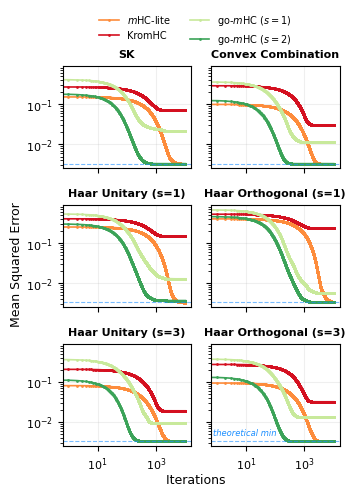

In [ ]:
# 2mins
import matplotlib.pyplot as plt
import numpy as np

methods = [
    generate_birkhoff_using_SK, 
    generate_birkhoff_using_BN_theorem,
    generate_birkhoff_using_haar_unitary(1), 
    generate_birkhoff_using_haar_orthogonal(1), 
    generate_birkhoff_using_haar_unitary(3), 
    generate_birkhoff_using_haar_orthogonal(3), 
]

fig, axs = plt.subplots(3, 2, figsize=(COLUMN_WIDTH, COLUMN_WIDTH * 1.3), sharex=True, sharey=True)
axs = axs.flatten()

for i, random_target_method in enumerate(methods):
    ax = axs[i]
    
    sweep_config = Config(
        n=4,
        noise_mag=1e-1,
        num_epochs=10_000,
        B=64,
        lr=0.001,
        sparsity=0,
        dataset_size=100,
        models_to_run=[go_mHC_run(s=1), go_mHC_run(s=2), KromHC_run(), mHC_lite_run()],
        random_target_generator=random_target_method
    )

    result = run_single_experiment(sweep_config)
    history = result[1]

    plot_data_map = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': history.get('go-$m$HC ($s=1$, Q)', []),
        'go-$m$HC ($s=2$)': history.get('go-$m$HC ($s=2$, Q)', []),
    }

    n_val = sweep_config.n

    if n_val.bit_count() == 1:
        plot_data_map['KromHC'] = history.get('KromHC', [])
    if n_val < 7:
        plot_data_map['$m$HC-lite'] = history.get('$m$HC-lite', [])

    # Plotting loop on the specific axis
    for color_idx, (label, data) in enumerate(plot_data_map.items()):
        if len(data) > 0 or label == " ":
            avg_data = np.mean(data, axis=0)
            ax.plot(avg_data, 
                    label=label, 
                    color=colors[color_idx],
                    alpha=0 if label == " " else 1, 
                    marker='.', 
                    markersize=2,
                    rasterized=True)

    ax.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.8, alpha=0.6)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(random_target_method.__name__.replace('_', ' ').replace("generate birkhoff using ", "").replace("(s", " (s").replace("BN theorem", "Convex Combination").replace("haar", "Haar").replace("unitary", "Unitary").replace("orthogonal", "Orthogonal"), fontsize=8, fontweight='bold')
    ax.grid(True, which="major", ls="-", alpha=0.2)

    if i == 5:
        ax.annotate('theoretical min', 
                    xy=(0.02, noise_floor / 1.2), 
                    xycoords=('axes fraction', 'data'),
                    xytext=(0, 5), 
                    textcoords='offset points',
                    ha='left', 
                    va='bottom',
                    color='dodgerblue', 
                    fontstyle='italic', 
                    fontsize=6)

fig.supxlabel("         Iterations", fontsize=9)
fig.supylabel("Mean Squared Error", fontsize=9)

handles, labels = ax.get_legend_handles_labels()

display_handles = [h for h, l in zip(handles, labels) if l.strip()]
display_labels = [l for l in labels if l.strip()]

fig.legend(display_handles, display_labels, 
           loc='upper center', 
           bbox_to_anchor=(0.55, 1.07), 
           ncol=2, 
           frameon=False, 
           fontsize=7)

plt.tight_layout()

# make ylabel closer
plt.subplots_adjust(left=0.17)
plt.subplots_adjust(bottom=0.1)
plt.savefig('different_target_sampling_methods.pdf', bbox_inches='tight', dpi=300)
plt.show()

Loading result from cache file: toy_model_cache.pkl


/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/torque/miniconda3/envs/torch/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Loading result from cache file: toy_model_cache.pkl
Loading result from cache file: toy_model_cache.pkl
Loading result from cache file: toy_model_cache.pkl


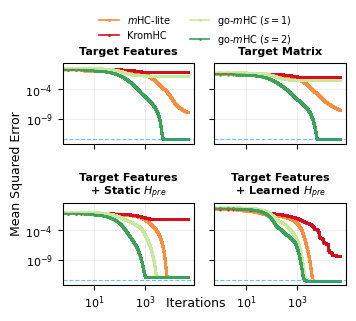

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

toy_models = [
    DatasetModel,
    TargetMatrixModel,
    DatasetModelWithStaticHpre,
    DatasetModelWithLearnedHpre
]
toy_model_names = [
    "Target Features",
    "Target Matrix",
    "Target Features\n+ Static $H_{pre}$",
    "Target Features\n+ Learned $H_{pre}$"
]

fig, axs = plt.subplots(2, 2, figsize=(COLUMN_WIDTH, 0.8*COLUMN_WIDTH ), sharex=True, sharey=True)
axs = axs.flatten()

for i, (toy_model, toy_model_name) in enumerate(zip(toy_models, toy_model_names)):
    ax = axs[i]
    
    sweep_config = Config(
        n=4,
        noise_mag=1e-6,
        num_epochs=50_000,
        B=64,
        lr=0.001,
        sparsity=0,
        dataset_size=100,
        models_to_run=[go_mHC_run(s=1), go_mHC_run(s=2), KromHC_run(), mHC_lite_run()],
        toy_model_type=toy_model
    )

    result = run_single_experiment(sweep_config)
    history = result[1]

    plot_data_map = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': history.get('go-$m$HC ($s=1$, Q)', []),
        'go-$m$HC ($s=2$)': history.get('go-$m$HC ($s=2$, Q)', []),
    }

    n_val = sweep_config.n

    if n_val.bit_count() == 1:
        plot_data_map['KromHC'] = history.get('KromHC', [])
    if n_val < 7:
        plot_data_map['$m$HC-lite'] = history.get('$m$HC-lite', [])

    # Plotting loop on the specific axis
    for color_idx, (label, data) in enumerate(plot_data_map.items()):
        if len(data) > 0 or label == " ":
            avg_data = np.mean(data, axis=0)
            if len(avg_data.shape) == 0:
                continue
            avg_data = np.minimum.accumulate(avg_data)
            ax.plot(avg_data, 
                    label=label, 
                    color=colors[color_idx],
                    alpha=0 if label == " " else 1, 
                    marker='.', 
                    markersize=2,
                    rasterized=True)

    noise_floor = (sweep_config.noise_mag ** 2) / 3
    ax.axhline(y=noise_floor, color='dodgerblue', linestyle='--', linewidth=0.8, alpha=0.6)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(toy_model_name, fontsize=8, fontweight='bold')
    ax.grid(True, which="major", ls="-", alpha=0.2)


fig.supxlabel("         Iterations", fontsize=9)
fig.supylabel("Mean Squared Error", fontsize=9)

handles, labels = ax.get_legend_handles_labels()
display_handles = [h for h, l in zip(handles, labels) if l.strip()]
display_labels = [l for l in labels if l.strip()]

fig.legend(display_handles, display_labels, 
           loc='upper center', 
           bbox_to_anchor=(0.55, 1.1), 
           ncol=2, 
           frameon=False, 
           fontsize=7)

plt.tight_layout()

plt.subplots_adjust(left=0.17)
plt.subplots_adjust(right=0.98)
plt.subplots_adjust(bottom=0.1)
plt.savefig('different_toy_models_methods.pdf', bbox_inches='tight', dpi=300)
plt.show()

# KromHC error with stream size

In [583]:
sweep_config = ConfigSweep(
    n=sorted([2**i for i in range(1, 9)] + [3**i for i in range(1, 6)]),
    sparsity=[0],
    num_epochs=[10_000],
    noise_mag=[1e-1],
    models_to_run=(KromHC_run(ik=2), KromHC_run(ik=3), KromHC_run(ik=4))
)

kromhc_sweep = run_experiment_sweep(sweep_config, double_tqdm=True)

Running 13 experiments...


0it [00:00, ?it/s]

Running experiment 1/13
Loading result from cache file: toy_model_cache.pkl


100%|██████████| 10000/10000 [00:06<00:00, 1663.56it/s]
1it [00:08,  8.08s/it]

Computed result and saved to cache file: toy_model_cache.pkl
Running experiment 2/13
Loading result from cache file: toy_model_cache.pkl


...

Computed result and saved to cache file: toy_model_cache.pkl
Running experiment 12/13
Loading result from cache file: toy_model_cache.pkl


100%|██████████| 10000/10000 [00:00<00:00, 4335197.93it/s]
12it [05:36, 35.57s/it]

Computed result and saved to cache file: toy_model_cache.pkl
Running experiment 13/13
Loading result from cache file: toy_model_cache.pkl


100%|██████████| 10000/10000 [06:30<00:00, 25.60it/s]
13it [12:09, 56.10s/it] 

Computed result and saved to cache file: toy_model_cache.pkl


<>:134: SyntaxWarning: invalid escape sequence '\p'
<>:134: SyntaxWarning: invalid escape sequence '\p'
/var/folders/fp/ywrwxn_122s537c0sm16gcxm0000gn/T/ipykernel_4729/183118257.py:134: SyntaxWarning: invalid escape sequence '\p'
  ax2.text(16, 16/35*3, '$\propto d$', color='k')


[2, 3, 4, 8, 9, 16, 27, 32, 64, 81, 128, 243, 256]


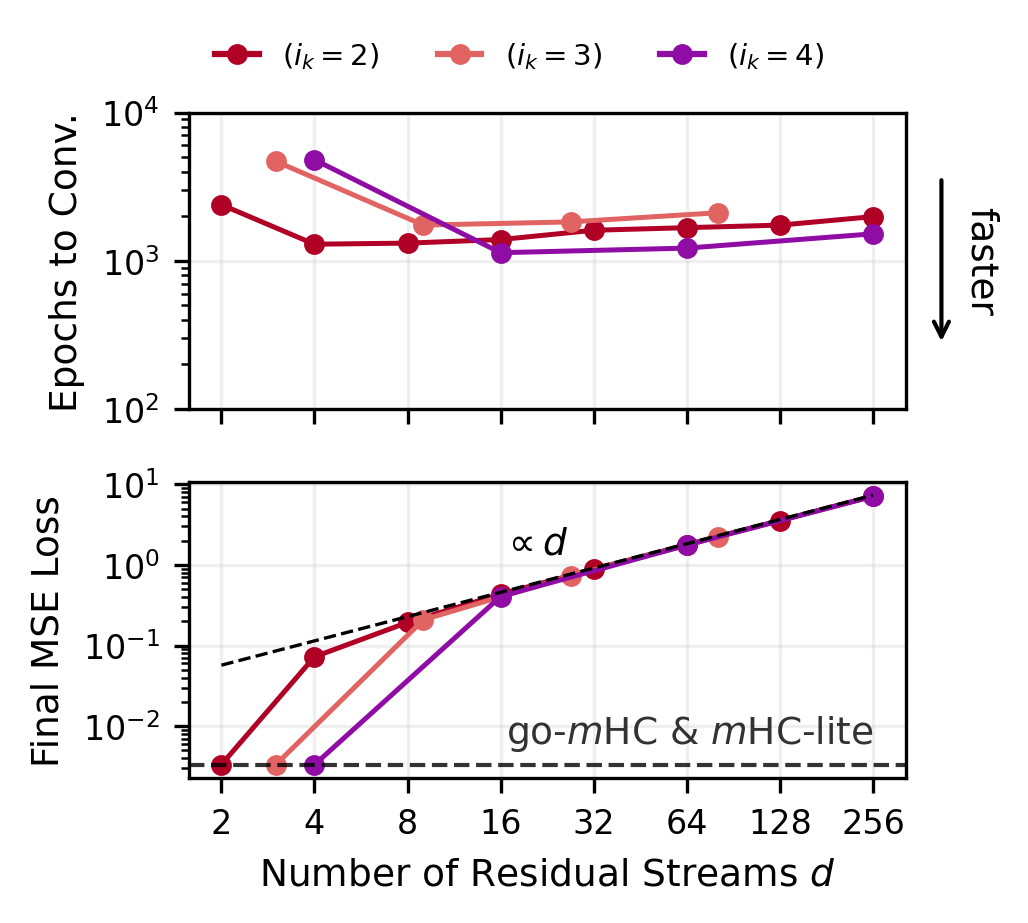

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.9) 

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True
})

def get_convergence_epoch(history_list, threshold_frac=0.05):
    if history_list is None or np.size(history_list) == 0:
        return None
    final_loss = history_list[-1]
    cutoff = final_loss * (1 + threshold_frac)
    indices = np.where(history_list <= cutoff)[0]
    return indices[0] if indices.size > 0 else None

# Data Setup
first_config = kromhc_sweep[0][0]
noise_floor = (first_config['noise_mag'] ** 2) / 3
dims = sorted(list(set(c['n'] for c, s, h in kromhc_sweep)))
print(dims)

colors_methods = {
    '($i_k=2$)': plt.cm.YlOrRd(0.9),
    '($i_k=3$)': plt.cm.plasma(0.6),
    '($i_k=4$)': plt.cm.plasma(0.3),
}

method_map = [
    ('($i_k=2$)', 'KromHC'),
    ('($i_k=3$)', 'KromHC ik=3'),
    ('($i_k=4$)', 'KromHC ik=4')
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIG_SIZE, sharex=True, dpi=300)

for method_name, history_key in method_map:
    color = colors_methods[method_name]
    xs, ys_conv, ys_loss = [], [], []
    reached_floor = []

    for d in dims:
        hist = None
        for config, summary, history in kromhc_sweep:
            if config['n'] == d:
                hist = history.get(history_key, [])
                break
        
        if 'KromHC' in method_name and d.bit_count() != 1: continue
        if method_name == 'mHC-lite' and d >= 7: continue
        if hist is None or np.size(hist) == 0: continue

        # Calculate metrics
        conv_list = [get_convergence_epoch(h) for h in hist]
        conv_list = [c for c in conv_list if c is not None]
        
        avg_conv = np.mean(conv_list) if conv_list else None
        final_loss = np.mean(np.min(hist, axis=1)) if len(hist) > 0 else None
        at_floor = final_loss is not None and final_loss <= noise_floor * 1.05

        if avg_conv is not None and final_loss is not None:
            xs.append(d)
            ys_conv.append(avg_conv)
            ys_loss.append(final_loss)
            reached_floor.append(at_floor)

    if xs:
        ls = '-'
        
        ax1.plot(xs, ys_conv, color=color, marker='o', linestyle=ls, 
                 markersize=4, rasterized=True)
        ax2.plot(xs, ys_loss, color=color, marker='o', linestyle=ls, 
                 markersize=4, rasterized=True)

ax1.set_yscale('log')
ax1.set_ylabel("Epochs to Conv.")
ax1.grid(True, which="major", ls="-", alpha=0.2)
ax1.set_yticks([100, 1000, 10000])

ax1.annotate('', xy=(1.05, 0.2), xytext=(1.05, 0.8), xycoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.0), annotation_clip=False)
ax1.annotate('faster', xy=(1.08, 0.5), xycoords='axes fraction',
             va='center', rotation=270, annotation_clip=False)

ax2.axhline(y=noise_floor, color='k', linestyle='--', linewidth=1.0, alpha=0.8)
ax2.text(max(dims), noise_floor*2.5, 'go-$m$HC & $m$HC-lite', va='center', ha='right', color='k', alpha=0.8)
ax2.set_yscale('log')
ax2.set_ylabel("Final MSE Loss")
ax2.set_xlabel("Number of Residual Streams $d$")
ax2.grid(True, which="major", ls="-", alpha=0.2)

ax2.set_xscale('log')
tick_vals = [2**i for i in range(1, int(np.log2(max(dims))) + 1)]
ax2.set_xticks(tick_vals)
ax2.set_xticklabels([str(v) for v in tick_vals])
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax2.set_xticks([], minor=True)

legend_handles = []
for m, _ in method_map:
    
    legend_handles.append(Line2D([0], [0], color=colors_methods[m], lw=1.5, 
                                 marker='o', markersize=4, label=m))

ax1.legend(handles=legend_handles, loc='lower left', bbox_to_anchor=(0, 1.05),
           ncol=3, frameon=False, handlelength=1.5)

ax2.plot(tick_vals, np.array(tick_vals)/35, color='k', linestyle='--', linewidth=0.8)
ax2.text(16, 16/35*3, '$\propto d$', color='k')

plt.savefig('kromhc_error_vs_d.pdf', bbox_inches='tight', dpi=300)
plt.show()